In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [28]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/pollution/1pasos_mlp_pollution.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2014-07-04 08:00:00,1.107677,1.108521
2014-07-04 09:00:00,0.932123,0.834230
2014-07-04 10:00:00,0.581013,0.702433
2014-07-04 11:00:00,0.493236,0.426289
2014-07-04 12:00:00,0.570041,0.440947


In [29]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/pollution/1pasos_lstm_pollution.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2014-07-04 08:00:00,1.107677,1.308270
2014-07-04 09:00:00,0.932123,1.014317
2014-07-04 10:00:00,0.581013,0.828207
2014-07-04 11:00:00,0.493236,0.571384
2014-07-04 12:00:00,0.570041,0.538443


In [30]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/pollution/1pasos_gru_pollution.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2014-07-04 08:00:00,1.107677,1.260741
2014-07-04 09:00:00,0.932123,0.968720
2014-07-04 10:00:00,0.581013,0.806056
2014-07-04 11:00:00,0.493236,0.555513
2014-07-04 12:00:00,0.570041,0.549727


In [31]:
datosCross= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/pollution/crossformerPollution.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2014-07-04 19:00:00,0.526152,1.274503
2014-07-04 20:00:00,1.030872,0.326384
2014-07-04 21:00:00,0.789484,1.113818
2014-07-04 22:00:00,0.559069,0.726848
2014-07-04 23:00:00,0.613930,0.531484


In [32]:
datosI= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/pollution/itransformerPollution.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2014-07-04 19:00:00,0.526152,1.260313
2014-07-04 20:00:00,1.030872,0.164478
2014-07-04 21:00:00,0.789484,1.082800
2014-07-04 22:00:00,0.559069,0.744419
2014-07-04 23:00:00,0.613930,0.498645


In [33]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/pollution/tftPollution.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2014-06-29 08:00:00,-0.252872,-0.575589
2014-06-29 09:00:00,-0.603982,-0.199151
2014-06-29 10:00:00,-0.702731,-0.580703
2014-06-29 11:00:00,-0.571065,-0.655650
2014-06-29 12:00:00,-0.439399,-0.523250


In [34]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])



In [35]:
final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-06-29 08:00:00,NaN,NaN,NaN,NaN,NaN,0.322717
2014-06-29 09:00:00,NaN,NaN,NaN,NaN,NaN,-0.404830
2014-06-29 10:00:00,NaN,NaN,NaN,NaN,NaN,-0.122028
2014-06-29 11:00:00,NaN,NaN,NaN,NaN,NaN,0.084585
2014-06-29 12:00:00,NaN,NaN,NaN,NaN,NaN,0.083851


In [36]:
final = final.dropna()
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-07-04 19:00:00,-0.707292,-0.797377,-0.773283,-0.748350,-0.734161,-0.718902
2014-07-04 20:00:00,0.590972,0.579776,0.630654,0.704488,0.866394,0.724737
2014-07-04 21:00:00,-0.332327,-0.396119,-0.368342,-0.324334,-0.293316,-0.343744
2014-07-04 22:00:00,-0.168352,-0.234259,-0.198816,-0.167779,-0.185350,-0.127303
2014-07-04 23:00:00,0.104329,0.009448,0.011469,0.082446,0.115285,0.142423


Muestra aleatoria

In [37]:
final = final.sample(frac=0.10, random_state=42)

In [38]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [39]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print(p)


8.764463542648186e-50


In [40]:
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print(p)


2.9898292770493364e-53


In [41]:
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print(p)


1.2364566064639535e-50


In [42]:
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print(p)


8.758424554220809e-51


In [43]:
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print(p)


5.454429828248548e-53


In [44]:
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print(p)


4.746217599884386e-51


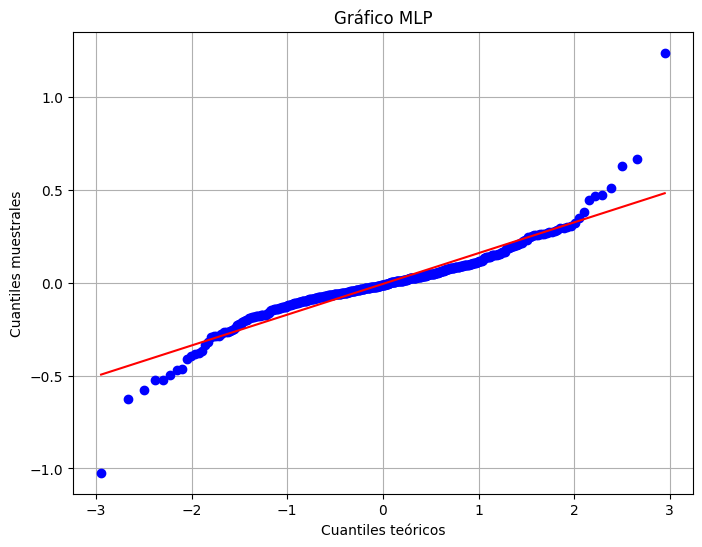

In [45]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP"], dist="norm", plot=plt)
plt.title('Gráfico MLP')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

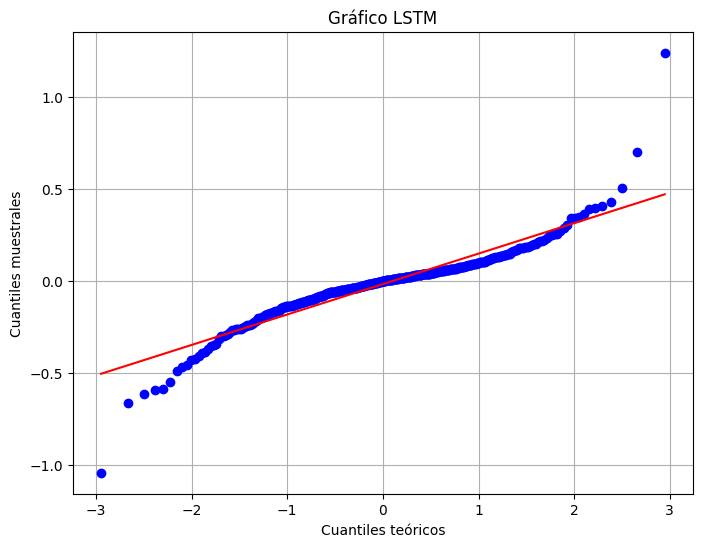

In [46]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM"], dist="norm", plot=plt)
plt.title('Gráfico LSTM')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

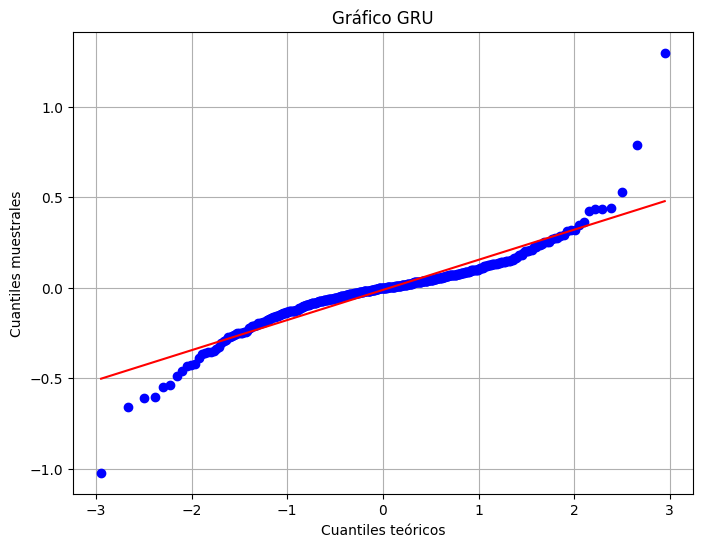

In [47]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU"], dist="norm", plot=plt)
plt.title('Gráfico GRU')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

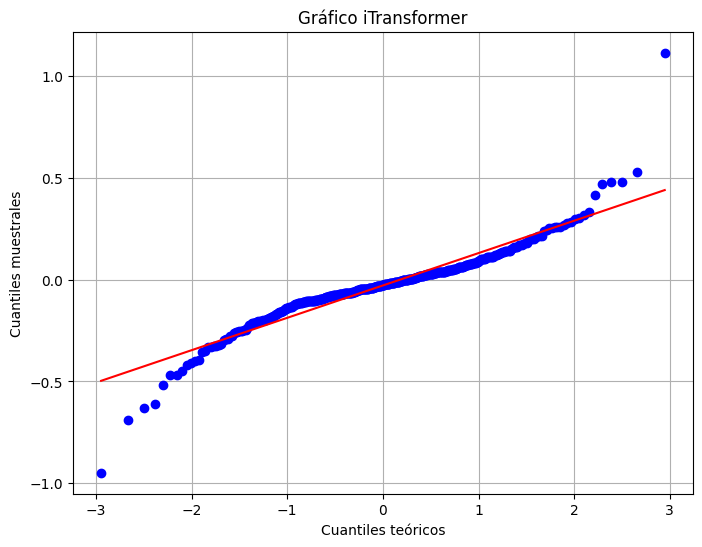

In [48]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer"], dist="norm", plot=plt)
plt.title('Gráfico iTransformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

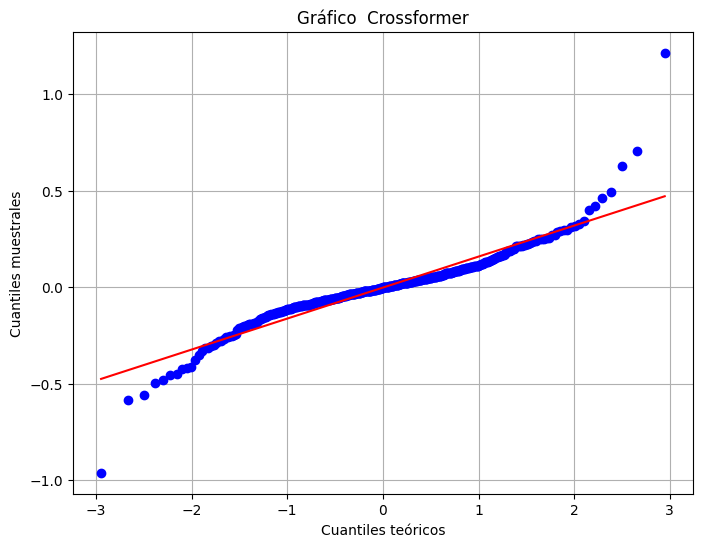

In [49]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer"], dist="norm", plot=plt)
plt.title('Gráfico  Crossformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

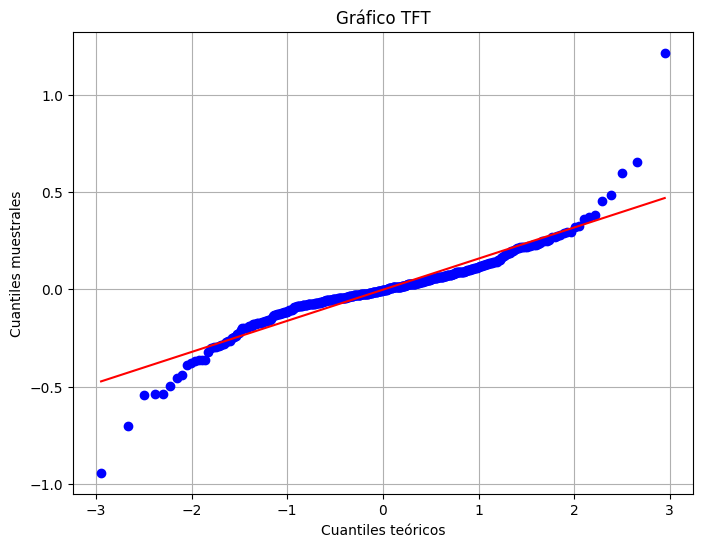

In [50]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT"], dist="norm", plot=plt)
plt.title('Gráfico TFT')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

In [51]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

1.0900736011753902e-27


In [52]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.00061,0.00912,0.00426
1,MLP vs GRU,0.04542,0.68126,0.09083
2,MLP vs Crossformer,0.04732,0.70978,0.09083
3,MLP vs iTransformer,0.00000,0.00000,0.00000
4,MLP vs TFT,0.00399,0.05986,0.01197
5,LSTM vs GRU,0.00048,0.00715,0.00381
6,LSTM vs Crossformer,0.00002,0.00027,0.00018
7,LSTM vs iTransformer,0.00144,0.02165,0.00866
8,LSTM vs TFT,0.00000,0.00000,0.00000
9,GRU vs Crossformer,0.00149,0.02229,0.00866
